VQR SIMULATION FOR SIN AND COS

sin(x) | BFGS: MSE = 8.3136e+00
sin(x) | COBYLA: MSE = 8.9730e+00
sin(x) | Nelder-Mead: MSE = 1.2387e+01
sin(x) | CG: MSE = 8.3137e+00
sin(x) | trust-constr: MSE = 8.3137e+00
sin(x) | Classical MSE: 5.1774e-03
Best optimizer for sin(x): BFGS



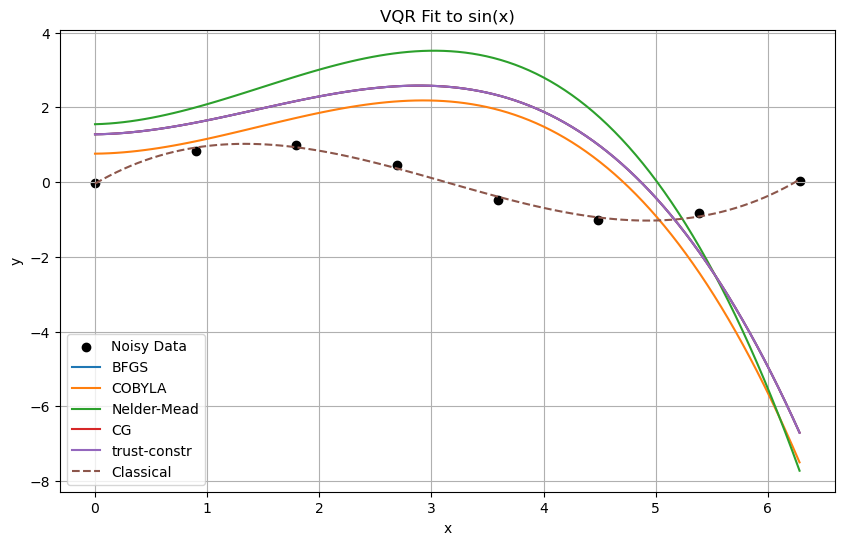

cos(x) | BFGS: MSE = 2.6077e+02
cos(x) | COBYLA: MSE = 2.5216e+02
cos(x) | Nelder-Mead: MSE = 1.0421e+01
cos(x) | CG: MSE = 2.6077e+02
cos(x) | trust-constr: MSE = 2.6077e+02
cos(x) | Classical MSE: 5.3071e-02
Best optimizer for cos(x): Nelder-Mead



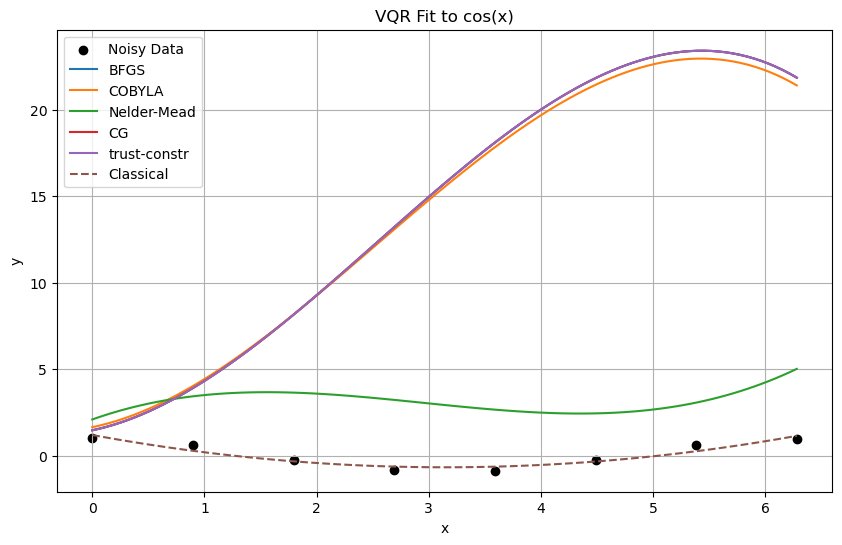

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize


np.random.seed(42)
random.seed(42)

# Quantum inner product estimation
def inner_prod(vec1, vec2): #creates function to estimate the inner product of two vectors
    if len(vec1) != len(vec2):
        raise ValueError('Vectors must be the same length')
        
    N = len(vec1) # N is the length of vector 1
    nqubits = math.ceil(np.log2(N)) #amount of qubits needed
    
    vec = np.concatenate((vec1, vec2)) / np.sqrt(2) #combine and entangle both vectors
    
    circ = QuantumCircuit(nqubits + 1) #creates circuit with nqubits plus one ancilla or control qubit
    circ.initialize(vec, range(nqubits + 1)) #loads this amplitude vector across all qubits (data + ancilla).
    circ.h(nqubits) #applies Hadamard to ancilla turning the ancilla amplitudes into constructive/destructive interference between vec1 and vec2 branches.
    
    state = Statevector.from_instruction(circ) #simulate and get full state vector
    real_amps = np.real(state.data) #retrieve the real amplitudes from the data and ansatz
    
    m_sum = sum(real_amps[l]**2 for l in range(N)) # sum the probs of basis states where ancilla == 0
    return 2 * m_sum - 1 ## recover ⟨vec1|vec2⟩ via P(0) = (1+⟨x|y⟩)/2

# Global values (shared between functions)
order = 3  # Degree of polynomial ansatz
N = 8      # Number of data points

# Cost function for polynomial ansatz
def calculate_cost_function_n(parameters):
    ansatz = parameters[0] * np.ones_like(x)  # initialize with a0

    for i in range(1, len(parameters)):
        ansatz += parameters[i] * x**i  # polynomial expansion adding a_i * x^i evaluated on x
    
    ansatz_norm = np.linalg.norm(ansatz) #normalize our ansatz == ||ansatz||
    ansatz_unit = ansatz / ansatz_norm #unit vector == ansatz / ||ansatz||
    #inner product expects and needs normalized vectors
    y_ansatz = ansatz_norm / ynorm * inner_prod(y, ansatz_unit) ## y_ansatz ≈ (‖ansatz‖/‖y‖) * ⟨ŷ | â⟩  → this equals ⟨y | ansatz⟩ / ‖y‖

    return (1 - y_ansatz) ** 2 # return the squared error. 

# Generate noisy data for a given function (sin, cos)
def generate_data(func, noise=0.05):
    x = np.linspace(0, 2*np.pi, N) ## N points between 0 and 2π
    y = func(x) + np.random.uniform(-noise, noise, N) #y = f(x) + uniform noise
    return x, y

# Run optimization for all methods
def run_optimizers(cost_fn, x0): #Iterates five optimization methods, calling minimize each with the same cost function and initial guess x0.
    methods = ["BFGS", "COBYLA", "Nelder-Mead", "CG", "trust-constr"]
    results = {}

    for method in methods: #for loop to loop through the optimizers names
        result = minimize(cost_fn, x0=x0, method=method, # starts at same initial guess for each optimizer and uses the current optimizer in the loop
                          options={'maxiter': 200}, tol=1e-6) #limits iterations to 200 and tolerance to 1e-6 (which is the stopping criteria for convergence)
        results[method] = result
    return results

# Fit function for plotting
def evaluate_fit(xfit, coeffs):
    yfit = np.zeros_like(xfit)
    for i, a in enumerate(coeffs):
        yfit += a * xfit**i
    return yfit

def run_vqr_for_function(func, label):
    global x, y, ynorm
    
    x, y = generate_data(func)
    ynorm = np.linalg.norm(y)
    y = y / ynorm
    
    x0 = [random.uniform(0, 2) for _ in range(order + 1)]
    results = run_optimizers(calculate_cost_function_n, x0)

    xfit = np.linspace(np.min(x), np.max(x), 100)

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y * ynorm, label="Noisy Data", color='black')

    # VQR FITS 
    for method, result in results.items():
        coeffs = result.x
        yfit = evaluate_fit(xfit, coeffs)
        plt.plot(xfit, yfit, label=method)

    # CLASSICAL FIT 
    classical_fit = np.polyfit(x, y * ynorm, order)[::-1]
    y_classical = evaluate_fit(xfit, classical_fit)
    plt.plot(xfit, y_classical, label="Classical", linestyle='dashed')

    # MSE ANALYSIS 
    mse_scores = {}

    for method, result in results.items():
        coeffs = result.x
        yfit_data = evaluate_fit(x, coeffs)
        mse = np.mean((y * ynorm - yfit_data)**2)
        mse_scores[method] = mse
        print(f"{label} | {method}: MSE = {mse:.4e}")

    # Classical MSE
    classical_coeffs = np.polyfit(x, y * ynorm, order)[::-1]
    y_classical_data = evaluate_fit(x, classical_coeffs)
    classical_mse = np.mean((y * ynorm - y_classical_data)**2)

    print(f"{label} | Classical MSE: {classical_mse:.4e}")

    # Best optimizer
    best_method = min(mse_scores, key=mse_scores.get)
    print(f"Best optimizer for {label}: {best_method}\n")

    # FINAL PLOT 
    plt.title(f"VQR Fit to {label}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run VQR for sin(x) and cos(x)
run_vqr_for_function(np.sin, "sin(x)")
run_vqr_for_function(np.cos, "cos(x)")
